## Импорты

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

c:\Users\Misha\PycharmProjects\netology\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## Пути и параметры

In [2]:
train_dir = 'train'
test_dir = 'test'

img_size = 224
batch_size = 32
seed = 42

## Формируем dataframe для train/test

In [3]:
train_files = [f for f in os.listdir(train_dir) if f.lower().endswith('.jpg')]
train_paths = [os.path.join(train_dir, f) for f in train_files]

train_labels = []
for f in train_files:
    if f.startswith('dog'):
        train_labels.append(1)
    else:
        train_labels.append(0)

train_df = pd.DataFrame({
    'filename': train_paths,
    'label': train_labels
})

test_files = [f for f in os.listdir(test_dir) if f.lower().endswith('.jpg')]
test_paths = [os.path.join(test_dir, f) for f in test_files]

test_ids = [int(os.path.splitext(f)[0]) for f in test_files]
test_df = pd.DataFrame({
    'filename': test_paths,
    'id': test_ids
}).sort_values('id').reset_index(drop=True)

train_df.head(), test_df.head()

(             filename  label
 0     train\cat.0.jpg      0
 1     train\cat.1.jpg      0
 2    train\cat.10.jpg      0
 3   train\cat.100.jpg      0
 4  train\cat.1000.jpg      0,
      filename  id
 0  test\1.jpg   1
 1  test\2.jpg   2
 2  test\3.jpg   3
 3  test\4.jpg   4
 4  test\5.jpg   5)

## Разделение train/val

In [4]:
train_part, val_part = train_test_split(
    train_df,
    test_size=0.2,
    random_state=seed,
    stratify=train_df['label']
)

train_part.shape, val_part.shape

((20000, 2), (5000, 2))

## Генераторы данных (аугментации + preprocess MobileNetV2)

In [5]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    shear_range=0.05,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_dataframe(
    train_part,
    x_col='filename',
    y_col='label',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='raw',
    shuffle=True,
    seed=seed
)

val_gen = val_datagen.flow_from_dataframe(
    val_part,
    x_col='filename',
    y_col='label',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='raw',
    shuffle=False
)

test_gen = test_datagen.flow_from_dataframe(
    test_df,
    x_col='filename',
    y_col=None,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode=None,
    shuffle=False
)

Found 20000 validated image filenames.
Found 5000 validated image filenames.
Found 12500 validated image filenames.


## Модель MobileNetV2

In [6]:
base = MobileNetV2(
    input_shape=(img_size, img_size, 3),
    include_top=False,
    weights='imagenet'
)
base.trainable = False

inputs = layers.Input(shape=(img_size, img_size, 3))
x = base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Обучение

In [7]:
callbacks = [
    ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
]

history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 259s 411ms/step - accuracy: 0.9686 - loss: 0.0901 - val_accuracy: 0.9802 - val_loss: 0.0492 - learning_rate: 0.0010
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 138s 220ms/step - accuracy: 0.9814 - loss: 0.0512 - val_accuracy: 0.9856 - val_loss: 0.0413 - learning_rate: 0.0010
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 137s 219ms/step - accuracy: 0.9833 - loss: 0.0464 - val_accuracy: 0.9856 - val_loss: 0.0396 - learning_rate: 0.0010
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 136s 217ms/step - accuracy: 0.9844 - loss: 0.0445 - val_accuracy: 0.9832 - val_loss: 0.0438 - learning_rate: 0.0010
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 138s 220ms/step - accuracy: 0.9839 - loss: 0.0432 - val_accuracy: 0.9872 - val_loss: 0.0370 - learning_rate: 0.0010
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 138s 221ms/step - accuracy: 0.9834 - loss: 0.0452 - val_accuracy: 0.9820 - val_loss: 0.0493 - learning_rate: 0.0010
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 137s 219ms/step - accura

## Fine-tuning

In [8]:
base.trainable = True

for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 151s 236ms/step - accuracy: 0.9615 - loss: 0.0985 - val_accuracy: 0.9782 - val_loss: 0.0600 - learning_rate: 1.0000e-05
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 147s 236ms/step - accuracy: 0.9740 - loss: 0.0645 - val_accuracy: 0.9842 - val_loss: 0.0422 - learning_rate: 1.0000e-05
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 148s 237ms/step - accuracy: 0.9797 - loss: 0.0523 - val_accuracy: 0.9832 - val_loss: 0.0419 - learning_rate: 5.0000e-06
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 148s 236ms/step - accuracy: 0.9815 - loss: 0.0497 - val_accuracy: 0.9856 - val_loss: 0.0369 - learning_rate: 5.0000e-06
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 146s 234ms/step - accuracy: 0.9811 - loss: 0.0494 - val_accuracy: 0.9852 - val_loss: 0.0357 - learning_rate: 2.5000e-06
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 146s 234ms/step - accuracy: 0.9812 - loss: 0.0485 - val_accuracy: 0.9850 - val_loss: 0.0364 - learning_rate: 2.5000e-06
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 

## Предсказание на test и submission.csv

In [11]:
model.load_weights('./best_model.keras', skip_mismatch=True)

pred = model.predict(test_gen, verbose=1).reshape(-1)
pred = np.clip(pred, 1e-6, 1 - 1e-6)

submission = pd.DataFrame({
    'id': test_df['id'].values,
    'label': pred
}).sort_values('id')

submission.to_csv('submission.csv', index=False)
submission.head()

c:\Users\Misha\PycharmProjects\netology\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:643: UserWarning: A total of 1 objects could not be loaded. Example error message for object <keras.src.optimizers.adam.Adam object at 0x00000276C23B51F0>:

'Unable to synchronously open object (unable to determine object type)'

List of objects that could not be loaded:
  warnings.warn(msg)


391/391 ━━━━━━━━━━━━━━━━━━━━ 97s 248ms/step


,id,label
0,1,0.999994
1,2,0.999988
2,3,0.999995
3,4,0.999982
4,5,0.001234


## График обучения

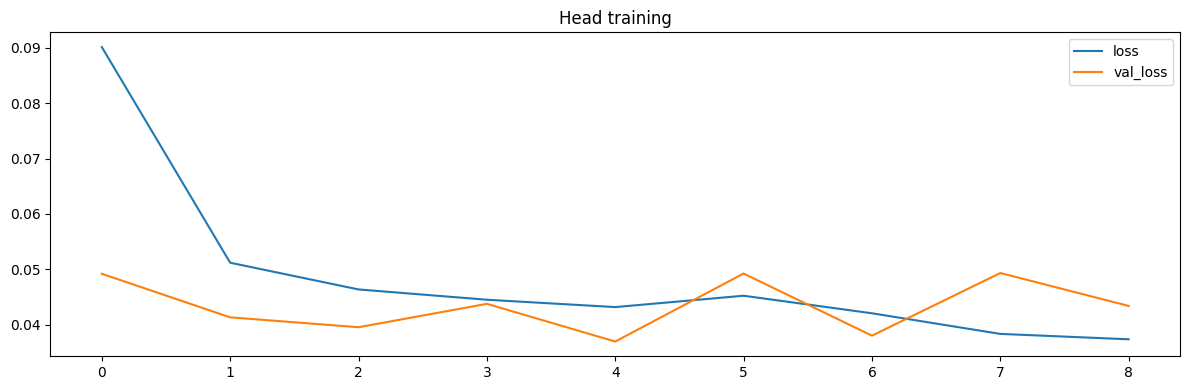

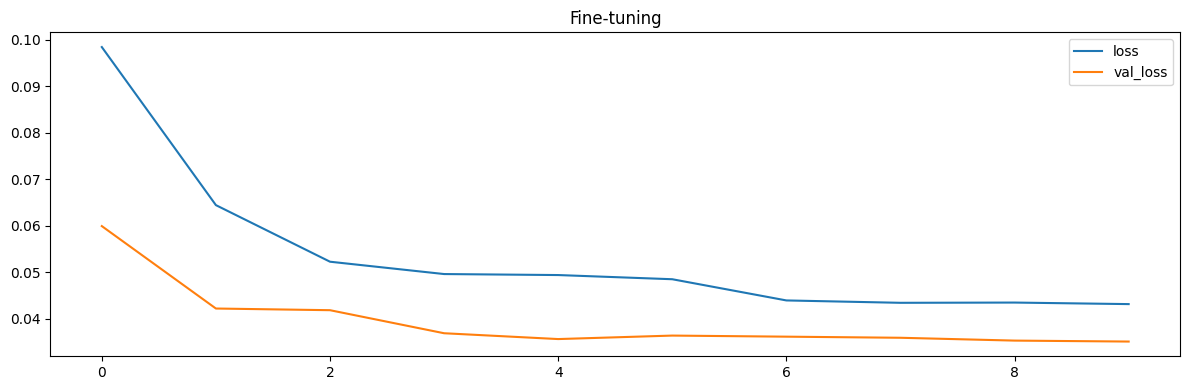

In [12]:
def plot_history(h, title):
    plt.figure(figsize=(12, 4))
    plt.plot(h.history['loss'], label='loss')
    plt.plot(h.history['val_loss'], label='val_loss')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(history1, 'Head training')
plot_history(history2, 'Fine-tuning')

В данной работе была обучена сверточная нейросеть для задачи бинарной классификации изображений
(кошки и собаки) на основе датасета Cats vs Dogs.

В качестве базовой архитектуры была использована модель MobileNetV2 с предобученными весами ImageNet.
Обучение проводилось в два этапа: сначала обучалась только классификационная голова модели при
замороженной сверточной базе, затем был выполнен fine-tuning верхних слоёв сети.
Для повышения качества и устойчивости модели использовались аугментации изображений и регуляризация.

Полученные предсказания были сохранены в формате submission.csv и отправлены в соревнование
Dogs vs Cats Redux на Kaggle. Итоговое значение метрики Log Loss составило 0.07447, что существенно
лучше требуемого порогового значения 0.3.

Таким образом, поставленная задача была успешно выполнена, а полученная модель демонстрирует
высокое качество классификации изображений.
